# House Price Prediction in India (Bangalore Housing Dataset)

## Project Type
Regression – Predicting House Prices

## Objective
The objective of this project is to build a regression model that predicts house prices based on various features such as location, area, number of bedrooms (BHK), bathrooms, and other property characteristics.

The project involves:
- Data exploration
- Data preprocessing
- Feature engineering
- Model building
- Model evaluation

## 1. Import Required Libraries

In this step, we import the Python libraries required for data analysis, visualization, and machine learning.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load and Preview the Dataset

The dataset used in this project is the **Bangalore Housing Price Dataset**.  
We load the dataset using pandas and preview the first few records to understand the structure of the data.

In [2]:
df = pd.read_csv(r'C:\Users\Admin\Spyder FirstDirectory\BHP.csv')
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


## 3. Dataset Structure

To understand the dataset better, we examine:
- The shape of the dataset (rows and columns)
- Column names
- Data types
- Missing values

In [3]:
df.shape
df.columns
df.info()
df.isnull().sum()
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


area_type        object
availability     object
location         object
size             object
society          object
total_sqft       object
bath            float64
balcony         float64
price           float64
dtype: object

## 4. Statistical Summary and Feature Types

The `describe()` function provides statistical insights for numerical columns such as mean, minimum, maximum, and standard deviation.

We also identify numerical and categorical features to understand how the data should be processed later.

In [4]:
df.describe()
numerical_features = df.select_dtypes(include = ["int64", "float64"]).columns
categorical_features = df.select_dtypes(include = ['object']).columns        

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
Index(['bath', 'balcony', 'price'], dtype='object')

Categorical Features:
Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft'],
      dtype='object')


## Phase 1 Summary

From the initial exploration of the dataset:

- The dataset contains housing data from Bangalore including location, area, BHK size, bathrooms, and price.
- The target variable is **price**, which we aim to predict using regression models.
- Some columns contain missing values that will need to be handled.
- The dataset contains both numerical and categorical features.

In the next phase, we will perform **data cleaning and preprocessing** to prepare the dataset for analysis and modeling.

## Phase 2: Data Cleaning and Preprocessing

Real-world datasets often contain missing values, inconsistent formats, and unnecessary columns.  
In this phase, we clean the dataset and prepare it for analysis and modeling.

The following steps will be performed:
- Remove unnecessary columns
- Handle missing values
- Convert categorical features into usable numerical formats
- Prepare the dataset for further analysis

In [5]:
df.drop("society", axis=1, inplace=True)
df.head()

df.isnull().sum()

df= df.dropna()

df.isnull().sum()

area_type       0
availability    0
location        0
size            0
total_sqft      0
bath            0
balcony         0
price           0
dtype: int64

In [6]:
df['bhk'] = df['size'].apply(lambda x: int(x.split(' ')[0]))

df[['size','bhk']].head()

df.drop("size", axis = 1, inplace = True)

In [7]:
def convert_sqft(x):
    token = str(x).split('-')

    if(len(token) == 2):
        return (float(token[0]) + float(token[1]))/2
    try:
        return float(x)
    except:
        return None

In [42]:
df["total_sqft"] = df["total_sqft"].apply(convert_sqft)
df = df.dropna()

df.info()
df.head()

df.to_csv("Cleaned_house_pred.csv", index = False)

<class 'pandas.core.frame.DataFrame'>
Index: 12668 entries, 0 to 13319
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   area_type       12668 non-null  object 
 1   location        12668 non-null  object 
 2   total_sqft      12668 non-null  float64
 3   bath            12668 non-null  float64
 4   balcony         12668 non-null  float64
 5   price           12668 non-null  float64
 6   bhk             12668 non-null  int64  
 7   price_per_sqft  12668 non-null  float64
dtypes: float64(5), int64(1), object(2)
memory usage: 890.7+ KB


## Phase 2 Summary

During the data cleaning phase, the following steps were performed:

- The **society** column was removed due to a large number of missing values.
- Missing values in the dataset were handled by removing incomplete records.
- The **size** column was converted into a new numerical feature called **BHK**.
- The **total_sqft** column was cleaned and converted into numeric values.

After these steps, the dataset is now cleaner and ready for **exploratory data analysis (EDA)**.

## Phase 3: Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand patterns, relationships, and distributions in the dataset.

In this phase we visualize the data using graphs and charts to identify:
- Price distribution
- Relationship between price and area
- Effect of number of bedrooms (BHK) on price
- Correlation between numerical features

### Price Distribution

This plot shows how house prices are distributed across the dataset.

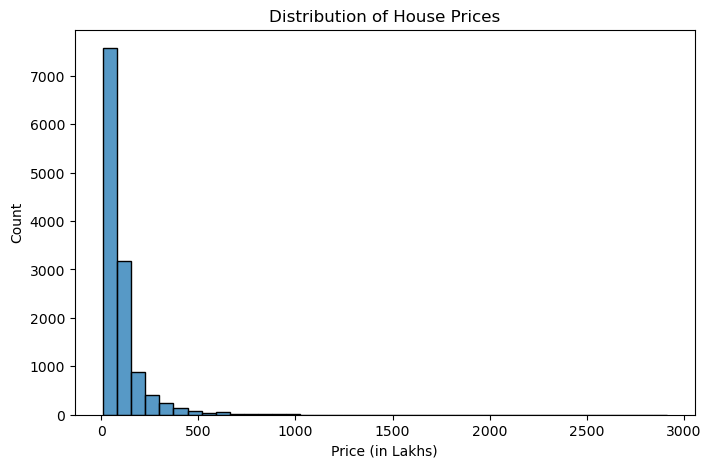

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=40)
plt.title("Distribution of House Prices")
plt.xlabel("Price (in Lakhs)")
plt.ylabel("Count")
plt.show()

### Price vs Total Area

This scatter plot shows the relationship between house price and total square footage.

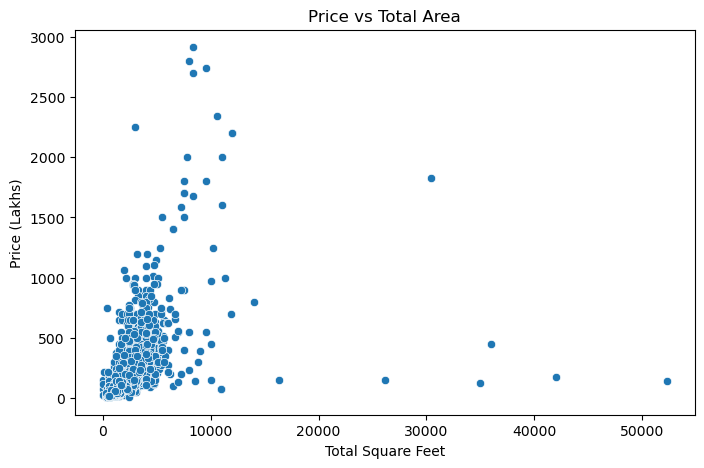

In [10]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['total_sqft'], y=df['price'])
plt.title("Price vs Total Area")
plt.xlabel("Total Square Feet")
plt.ylabel("Price (Lakhs)")
plt.show()

### Price vs Number of Bedrooms (BHK)

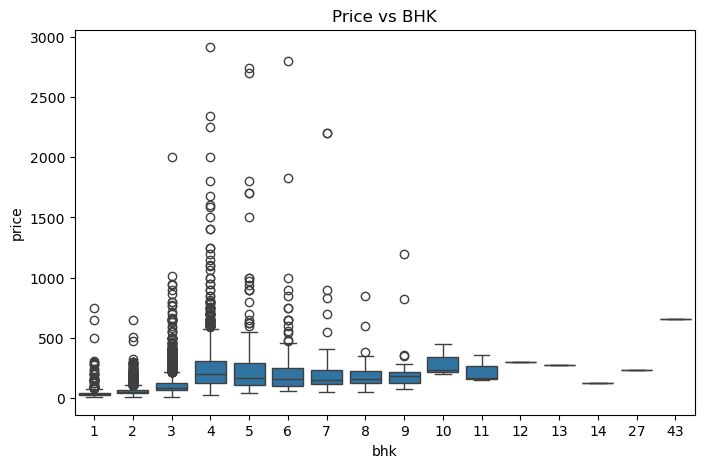

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['bhk'], y=df['price'])
plt.title("Price vs BHK")
plt.show()

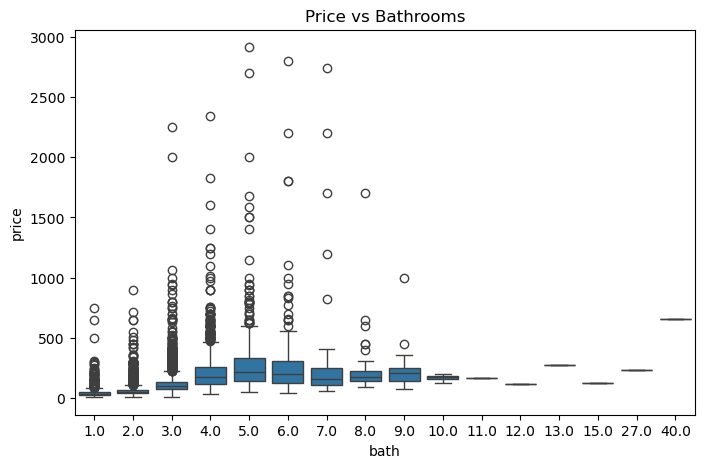

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['bath'], y=df['price'])
plt.title("Price vs Bathrooms")
plt.show()

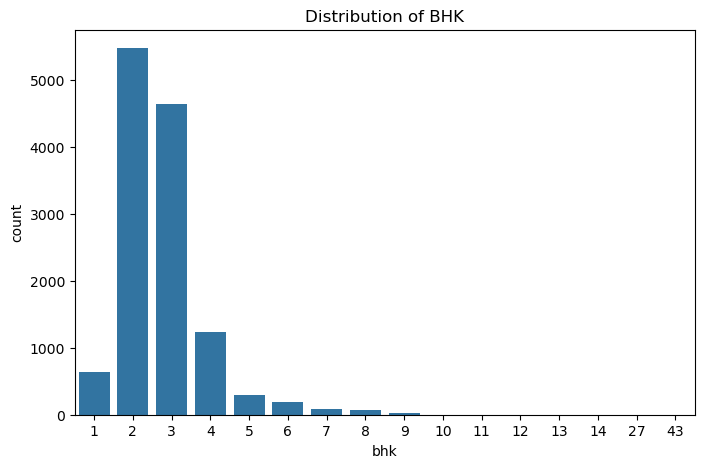

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(x=df['bhk'])
plt.title("Distribution of BHK")
plt.show()

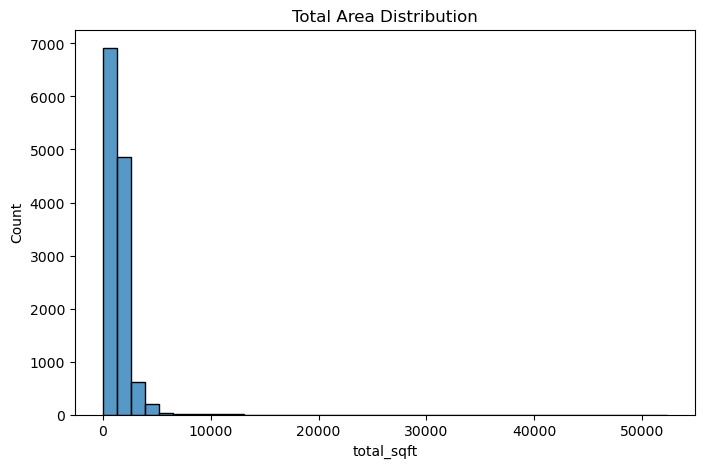

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df['total_sqft'], bins=40)
plt.title("Total Area Distribution")
plt.show()

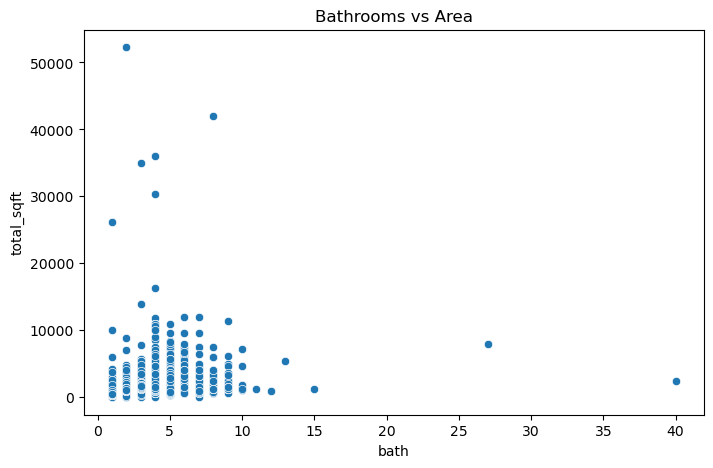

In [15]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['bath'], y=df['total_sqft'])
plt.title("Bathrooms vs Area")
plt.show()

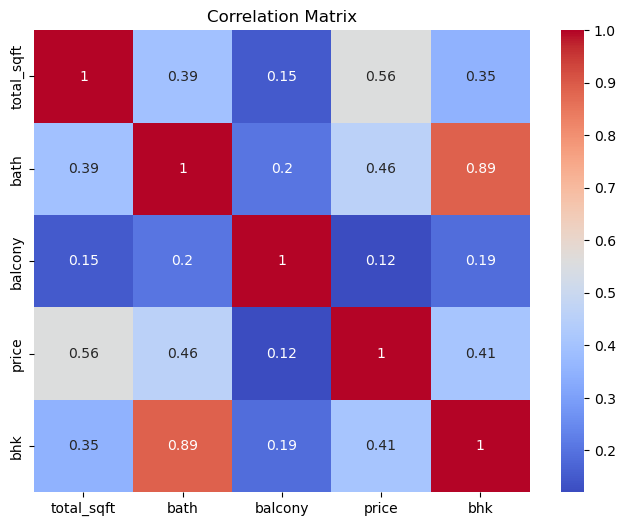

In [16]:
numeric_df = df.select_dtypes(include=['float64','int64'])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

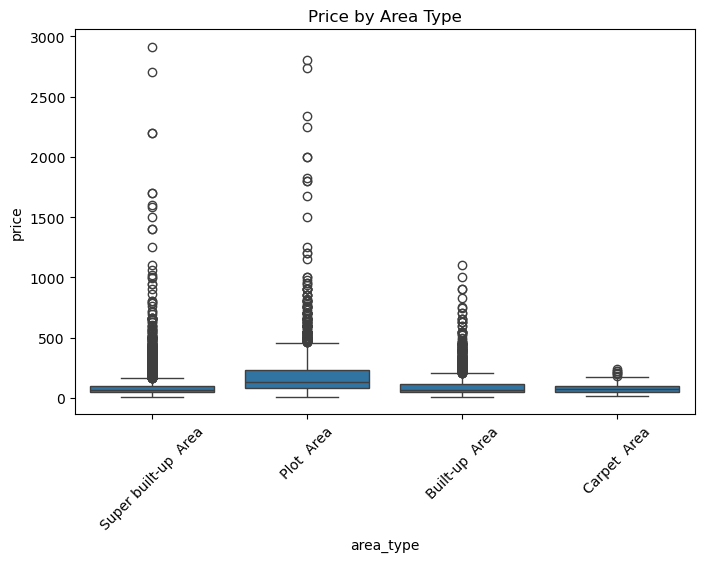

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['area_type'], y=df['price'])
plt.xticks(rotation=45)
plt.title("Price by Area Type")
plt.show()

## Phase 3 Summary

From the exploratory analysis we observe:

- Houses with larger **square footage** tend to have higher prices.
- Properties with more **BHK and bathrooms** generally have higher prices.
- Price distribution shows that most houses fall within a moderate price range.
- Some extreme values indicate potential outliers in the dataset.

These insights will help guide the **feature engineering and model building stage**.

## Phase 4: Feature Engineering

Feature engineering involves creating new useful features and modifying existing ones to improve model performance.

In this phase we:
- Create a new feature called **price_per_sqft**
- Reduce the number of unique locations
- Remove unnecessary or redundant features

In [18]:
df["price_per_sqft"] = (df["price"] * 100000)/df["total_sqft"]

df[['price','total_sqft','price_per_sqft']].head()

,price,total_sqft,price_per_sqft
0,39.07,1056.0,3699.810606
1,120.00,2600.0,4615.384615
2,62.00,1440.0,4305.555556
3,95.00,1521.0,6245.890861
4,51.00,1200.0,4250.000000


In [24]:
print(df['location'].nunique())

df.location = df.location.apply(lambda x: x.strip())
location_stats = df.groupby('location')['location'].count().sort_values(ascending=False)
location_stats

print(len(location_stats[location_stats <= 10]))

location_stats_less_than_10 = location_stats[location_stats <= 10]

df.location = df.location.apply(lambda x: 'other' if x in location_stats_less_than_10 else x)

print(df.location.nunique())

236
0
236


In [26]:
df.drop("availability", axis=1, errors = "ignore", inplace=True)

In [21]:
df.head()

,area_type,location,total_sqft,bath,balcony,price,bhk,price_per_sqft
0,Super built-up Area,Electronic City Phase II,1056.0,2.0,1.0,39.07,2,3699.810606
1,Plot Area,Chikka Tirupathi,2600.0,5.0,3.0,120.00,4,4615.384615
2,Built-up Area,Uttarahalli,1440.0,2.0,3.0,62.00,3,4305.555556
3,Super built-up Area,Lingadheeranahalli,1521.0,3.0,1.0,95.00,3,6245.890861
4,Super built-up Area,Kothanur,1200.0,2.0,1.0,51.00,2,4250.000000


## Phase 4 Summary

In the feature engineering phase:

- A new feature **price_per_sqft** was created to better represent property value.
- Rare locations were grouped into a category called **"other"** to reduce dimensionality.
- The **availability** column was removed as it does not significantly impact price prediction.

The dataset is now optimized for building machine learning models.

## Phase 5: Model Building

In this phase, we build machine learning models to predict house prices.

The following regression models will be trained:
- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

The dataset will first be prepared by encoding categorical variables and splitting into training and testing sets.

In [27]:
df_encoded = pd.get_dummies(df, columns=['area_type','location'], drop_first=True)
df_encoded.head()

,total_sqft,bath,balcony,price,bhk,price_per_sqft,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area,location_1st Phase JP Nagar,...,location_Vishveshwarya Layout,location_Vishwapriya Layout,location_Vittasandra,location_Whitefield,location_Yelachenahalli,location_Yelahanka,location_Yelahanka New Town,location_Yelenahalli,location_Yeshwanthpur,location_other
0,1056.0,2.0,1.0,39.07,2,3699.810606,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,2600.0,5.0,3.0,120.00,4,4615.384615,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1440.0,2.0,3.0,62.00,3,4305.555556,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1521.0,3.0,1.0,95.00,3,6245.890861,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
4,1200.0,2.0,1.0,51.00,2,4250.000000,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False


In [28]:
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

### Step 5: Train Linear Regression Model

Linear Regression is a simple algorithm that models the relationship between features and the target variable using a linear equation.

In [32]:
lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

### Step 6: Train Decision Tree Regressor

Decision Trees split the dataset into smaller subsets based on feature values.  
They can capture nonlinear relationships in the data.

In [33]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

### Step 7: Train Random Forest Regressor

Random Forest is an ensemble learning method that builds multiple decision trees and combines their predictions.  
It often provides better accuracy and reduces overfitting.

In [34]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

## Phase 5 Summary

In this phase, categorical variables were encoded using One-Hot Encoding, and the dataset was split into training and testing sets.

Three regression models were trained:
- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

In the next phase, we will evaluate these models using performance metrics such as RMSE, MAE, and R² score to determine which model performs best.

## Phase 6: Model Evaluation and Interpretation

After training the regression models, we evaluate their performance using standard regression metrics.

The following metrics are used:
- **RMSE (Root Mean Squared Error)** – measures prediction error magnitude
- **MAE (Mean Absolute Error)** – average absolute difference between actual and predicted values
- **R² Score** – measures how well the model explains variance in the data

These metrics help determine which model performs best.

### Import Evaluation Metrics

In [35]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

### Model Evaluation Function

To simplify evaluation, we create a function that calculates RMSE, MAE, and R² score for each model.

In [36]:
def evaluate_model(y_test, predictions):

    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    print("RMSE:", rmse)
    print("MAE:", mae)
    print("R2 Score:", r2)

### Linear Regression Performance

In [37]:
evaluate_model(y_test, pred_lr)

RMSE: 109.4292499795051
MAE: 37.502772275698035
R2 Score: 0.4425829242360636


### Decision Tree Performance

In [38]:
evaluate_model(y_test, pred_dt)

RMSE: 34.766336814697965
MAE: 3.981337805840568
R2 Score: 0.9437359111817681


### Random Forest Performance

In [39]:
evaluate_model(y_test, pred_rf)

RMSE: 31.59609249582767
MAE: 2.849336424625099
R2 Score: 0.9535291970562131


### Top Features Affecting House Price

In [40]:
feature_importance = rf.feature_importances_

features = pd.Series(feature_importance, index=X.columns)
top_features = features.sort_values(ascending=False).head(5)

top_features

total_sqft               0.565111
price_per_sqft           0.421588
location_Bommenahalli    0.008095
bhk                      0.001216
bath                     0.000844
dtype: float64

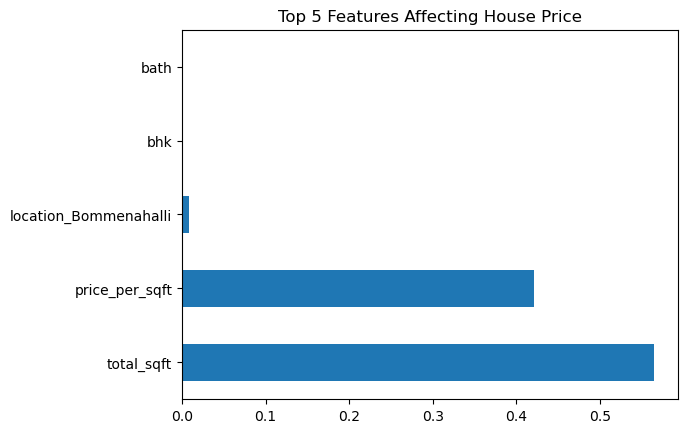

In [41]:
top_features.plot(kind='barh')
plt.title("Top 5 Features Affecting House Price")
plt.show()

## Final Insights

From the model evaluation:

- The **Random Forest model typically performs best** because it captures nonlinear relationships between housing features and price.
- **Total square footage** and **price per square foot** have strong influence on house price.
- Houses with more **BHK and bathrooms** tend to be more expensive.
- **Location** also significantly impacts housing prices.

These insights can help real estate companies, property buyers, and investors better understand the key factors affecting housing prices.

## Project Conclusion

In this project, we developed a regression model to predict house prices using the Bangalore Housing Dataset.

The workflow included:
1. Data loading and exploration
2. Data cleaning and preprocessing
3. Exploratory data analysis
4. Feature engineering
5. Model building
6. Model evaluation

Among the models tested, **Random Forest Regressor provided the best performance**, demonstrating its ability to capture complex patterns in housing data.

This model can be used as a foundation for building real estate price prediction systems.